In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

Text(0, 0.5, 'qwerty dimension 2')

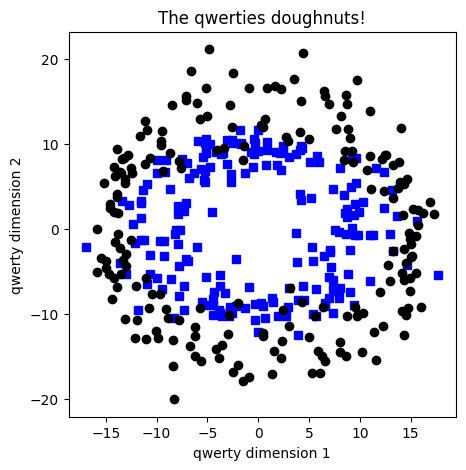

In [2]:
nPerClust = 200

th = np.linspace(0, 4*np.pi, nPerClust)
r1 = 10
r2 = 15

a = [r1*np.cos(th) + np.random.randn(nPerClust)*3,
     r1*np.sin(th) + np.random.randn(nPerClust)]
b = [r2*np.cos(th) + np.random.randn(nPerClust),
     r2*np.sin(th) + np.random.randn(nPerClust)*3]

labels_np = np.vstack((np.zeros((nPerClust,1)),np.ones((nPerClust,1))))

data_np = np.hstack((a,b)).T

data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0], data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0], data[np.where(labels==1)[0],1],'ko')
plt.title("The qwerties doughnuts!")
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')

In [3]:
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, test_size=.2)

train_data = TensorDataset(train_data, train_labels)
test_data = TensorDataset(test_data, test_labels)

batchsize = 16
train_loader = DataLoader(train_data, batch_size=batchsize, shuffle=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [4]:
class theModelClass(nn.Module):
    def __init__(self, dropoutRate):
        super().__init__()

        self.input = nn.Linear(2, 128)
        self.hidden = nn.Linear(128, 128)
        self.output = nn.Linear(128, 1)

        self.dr = dropoutRate

    def forward(self, x):
        x  = F.relu(self.input(x))

        x = F.dropout(x, p=self.dr, training=self.training)

        x = F.relu(self.hidden(x))

        x = F.dropout(x, p=self.dr, training=self.training)

        x = self.output(x)

        return x

In [5]:
tmpnet = theModelClass(.25)

tmpdata = torch.randn((10,2))
yhat = tmpnet(tmpdata)
yhat

tensor([[ 0.0424],
        [-0.0102],
        [-0.0593],
        [-0.0795],
        [ 0.0278],
        [-0.0238],
        [ 0.0384],
        [ 0.0151],
        [ 0.1290],
        [ 0.0070]], grad_fn=<AddmmBackward0>)

In [6]:
def createANewModel(dropoutrate):

    ANNQC = theModelClass(dropoutrate)

    lossfun = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.SGD(ANNQC.parameters(), lr=.002)

    return ANNQC, lossfun, optimizer

In [7]:
numepochs = 1000

def trainTheModel(ANNQC, lossfun, optimizer):

    trainAcc = []
    testAcc = []

    for epochi in range(numepochs):

        ANNQC.train()
        
        batchAcc = []
        for X, y in train_loader:
            yHat = ANNQC(X)
            loss = lossfun(yHat, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batchAcc.append(100*torch.mean(((yHat>.5)==y).float()).item())

        trainAcc.append(np.mean(batchAcc))

        ANNQC.eval()
        X, y = next(iter(test_loader))
        yHat = ANNQC(X)
        testAcc.append(100*torch.mean(((yHat>.5)==y).float()).item())

    return trainAcc, testAcc
        
    

In [8]:
dropoutrate = .0
ANNQC, lossfun, optimizer = createANewModel(dropoutrate)

trainAcc, testAcc = trainTheModel(ANNQC, lossfun, optimizer)

AttributeError: 'float' object has no attribute 'items'

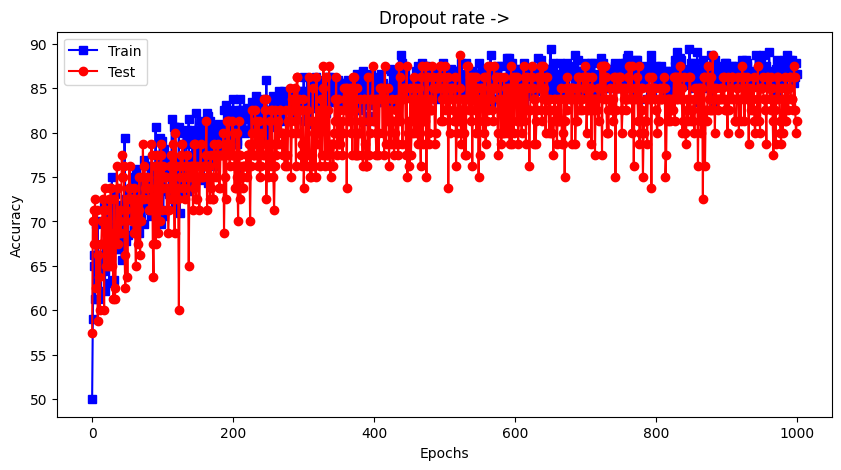

In [9]:
fig = plt.figure(figsize=(10,5))

plt.plot(trainAcc, 'bs-')
plt.plot(testAcc, 'ro-')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'])
plt.title('Dropout rate ->', dropoutrate)

plt.show()

In [10]:
def smooth(x, k=5):
    return np.convolve(x, np.ones(k)/k, mode="same")

AttributeError: 'float' object has no attribute 'items'

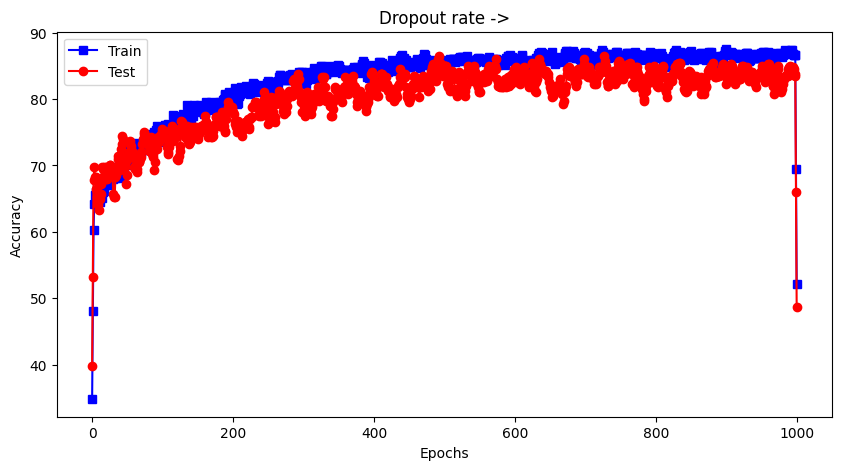

In [11]:
fig = plt.figure(figsize=(10,5))

plt.plot(smooth(trainAcc), 'bs-')
plt.plot(smooth(testAcc), 'ro-')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'])
plt.title('Dropout rate ->', dropoutrate)

plt.show()

In [12]:
dropoutRates = np.arange(10)/10
results = np.zeros((len(dropoutRates),2))

for di in range(len(dropoutRates)):

    ANNQC, lossfun, optimizer = createANewModel(dropoutRates[di])
    trainAcc, testAcc = trainTheModel(ANNQC, lossfun, optimizer)

    results[di,0] = np.mean(trainAcc[-100])
    results[di,1] = np.mean(testAcc[-100])

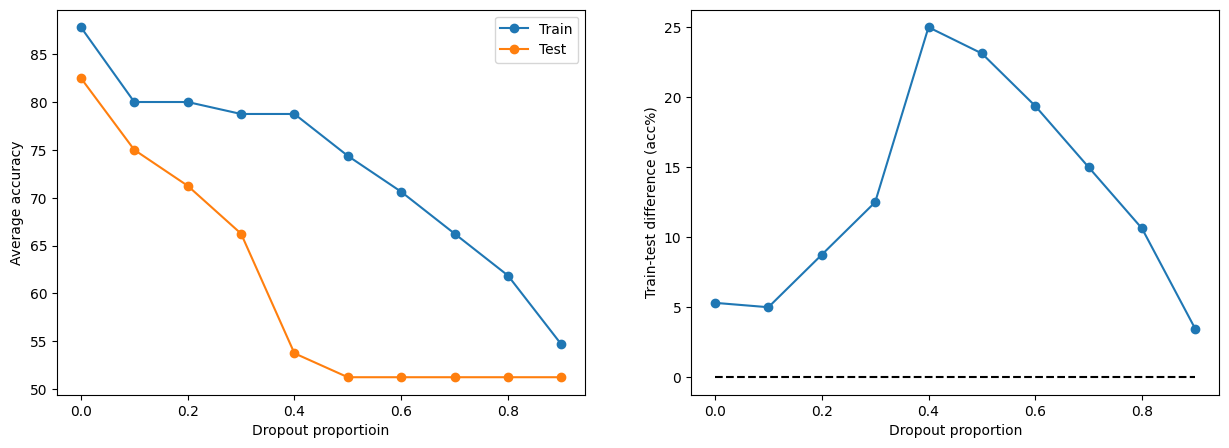

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(dropoutRates, results, 'o-')
ax[0].set_xlabel('Dropout proportioin')
ax[0].set_ylabel('Average accuracy')
ax[0].legend(['Train', 'Test'])

ax[1].plot(dropoutRates, -np.diff(results, axis=1), 'o-')
ax[1].plot([0,.9], [0,0], 'k--')
ax[1].set_xlabel('Dropout proportion')
ax[1].set_ylabel('Train-test difference (acc%)')

plt.show()